In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt


# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
test_results_df = pd.read_json(
    "../data/processed/"
    "final_test_predictions.jsonl",
    lines=True
)

print(
    "Test records:",
    len(test_results_df)
)

Test records: 555


In [5]:
y_test = (
    test_results_df["actual"]
)

final_predictions = (
    test_results_df["predicted"]
)

In [6]:
final_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score"
        ],
        "Score": [
            accuracy_score(
                y_test,
                final_predictions
            ),
            precision_score(
                y_test,
                final_predictions
            ),
            recall_score(
                y_test,
                final_predictions
            ),
            f1_score(
                y_test,
                final_predictions
            )
        ]
    }
)

final_results

,Metric,Score
0,Accuracy,0.783784
1,Precision,0.570513
2,Recall,0.626761
3,F1-score,0.597315


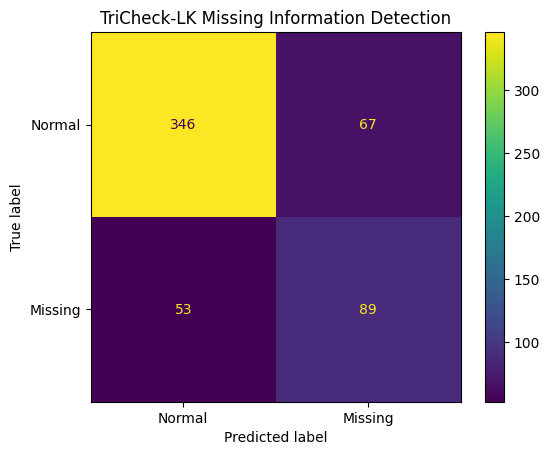

In [7]:
# Final confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=[
        "Normal",
        "Missing"
    ]
)

plt.title(
    "TriCheck-LK Missing Information Detection"
)

plt.show()

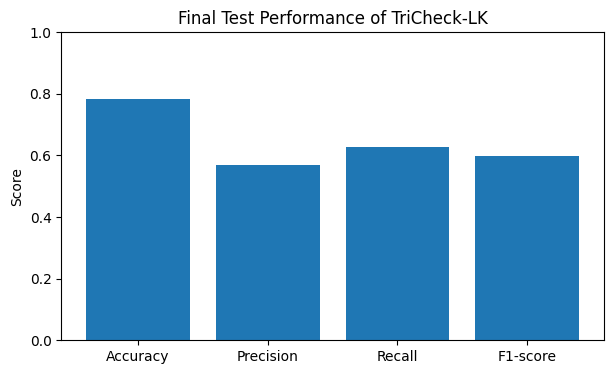

In [8]:
plt.figure(
    figsize=(7, 4)
)

plt.bar(
    final_results["Metric"],
    final_results["Score"]
)

plt.ylim(
    0,
    1
)

plt.title(
    "Final Test Performance of TriCheck-LK"
)

plt.ylabel(
    "Score"
)

plt.show()

In [10]:
model_results = pd.read_csv(
    "../data/processed/model_validation_results.csv"
)

model_results

,model,accuracy,precision,recall,f1_score
0,SVM (RBF),0.750343,0.440816,0.705882,0.542714
1,Random Forest,0.748971,0.436441,0.673203,0.529563
2,Logistic Regression,0.716049,0.400735,0.712418,0.512941
3,HistGradientBoosting,0.716049,0.392857,0.647059,0.488889


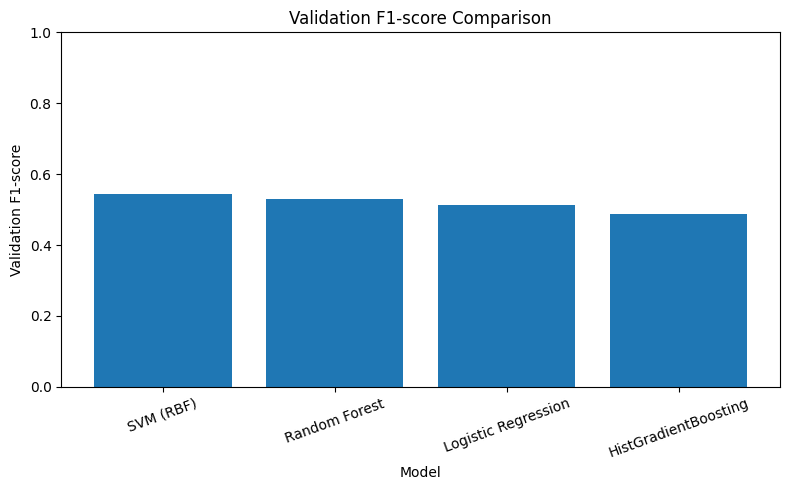

In [11]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    model_results["model"],
    model_results["f1_score"]
)

plt.ylim(
    0,
    1
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Validation F1-score"
)

plt.title(
    "Validation F1-score Comparison"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [12]:
#Precision–Recall imports
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

In [13]:
#get saved probabilities
test_probabilities = (
    test_results_df[
        "probability"
    ]
)

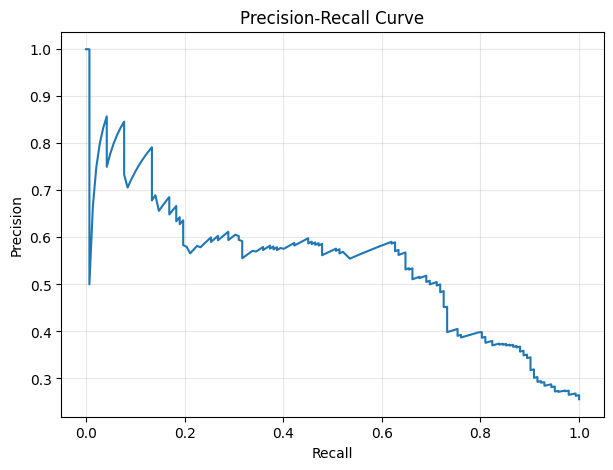

Average Precision: 0.5448


In [14]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_test,
        test_probabilities
    )
)

average_precision = (
    average_precision_score(
        y_test,
        test_probabilities
    )
)


plt.figure(
    figsize=(7, 5)
)

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.grid(
    alpha=0.3
)

plt.show()


print(
    "Average Precision:",
    round(
        average_precision,
        4
    )
)

In [15]:
final_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "Average Precision"
        ],
        "Score": [
            0.7838,
            0.5705,
            0.6268,
            0.5973,
            0.5448
        ]
    }
)

final_summary

,Metric,Score
0,Accuracy,0.7838
1,Precision,0.5705
2,Recall,0.6268
3,F1-score,0.5973
4,Average Precision,0.5448


## Final Multilingual Evaluation

The final TriCheck-LK system uses separate language-specific missing-information
detectors for English, Sinhala, and Tamil.

English was evaluated on a fresh holdout set of previously unused circulars
after the English detector was improved. Sinhala and Tamil retain their
previous untouched test-set results.

In [1]:
import pandas as pd

final_multilingual_results = pd.DataFrame({
    "Language": [
        "English",
        "Sinhala",
        "Tamil"
    ],

    "Accuracy": [
        0.6780,
        0.7838,
        0.8126
    ],

    "Precision": [
        0.3742,
        0.5705,
        0.6101
    ],

    "Recall": [
        0.8182,
        0.6268,
        0.6978
    ],

    "F1-score": [
        0.5136,
        0.5973,
        0.6510
    ]
})

final_multilingual_results

,Language,Accuracy,Precision,Recall,F1-score
0,English,0.6780,0.3742,0.8182,0.5136
1,Sinhala,0.7838,0.5705,0.6268,0.5973
2,Tamil,0.8126,0.6101,0.6978,0.6510


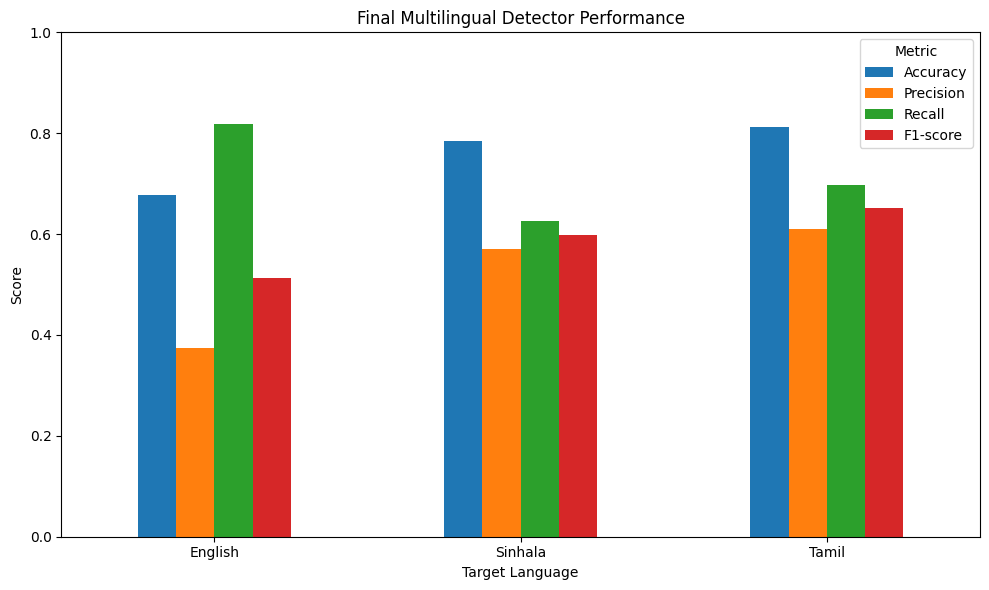

In [2]:
import matplotlib.pyplot as plt


plot_df = (
    final_multilingual_results
    .set_index("Language")
)


ax = plot_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)


plt.title(
    "Final Multilingual Detector Performance"
)

plt.xlabel(
    "Target Language"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

plt.show()

English → highest Recall (0.8182), but lowest Precision (0.3742)
Sinhala → more balanced performance
Tamil   → highest Accuracy (0.8126) and F1-score (0.6510)

## Confusion Matrix Analysis

Confusion matrices were used to examine the number of correctly and incorrectly
classified missing-information regions for each target language.

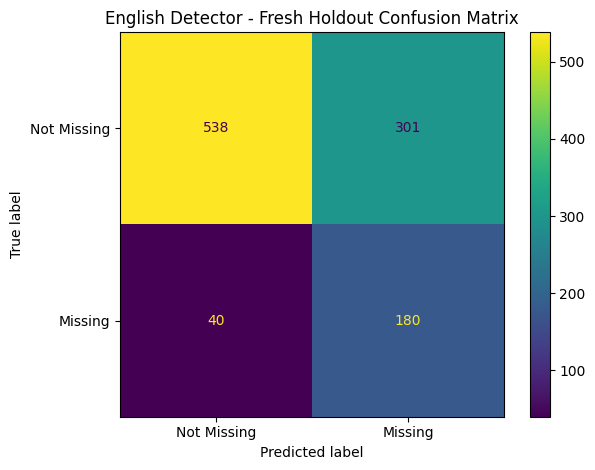

In [3]:
#English
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


english_cm = np.array([
    [538, 301],
    [40, 180]
])


ConfusionMatrixDisplay(
    confusion_matrix=english_cm,
    display_labels=[
        "Not Missing",
        "Missing"
    ]
).plot(
    values_format="d"
)

plt.title(
    "English Detector - Fresh Holdout Confusion Matrix"
)

plt.tight_layout()
plt.show()

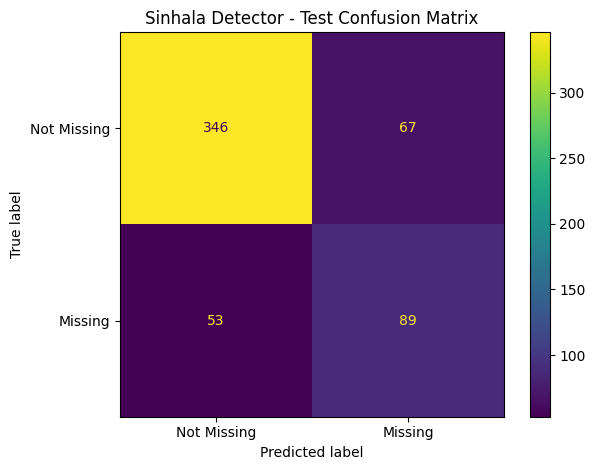

In [4]:
#Sinhala
sinhala_cm = np.array([
    [346, 67],
    [53, 89]
])


ConfusionMatrixDisplay(
    confusion_matrix=sinhala_cm,
    display_labels=[
        "Not Missing",
        "Missing"
    ]
).plot(
    values_format="d"
)

plt.title(
    "Sinhala Detector - Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

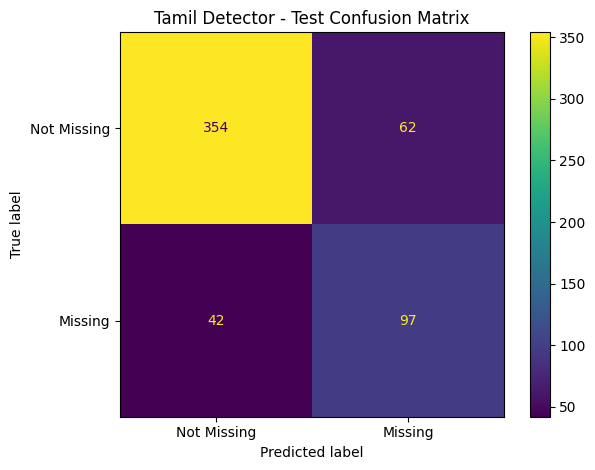

In [5]:
#Tamil
tamil_cm = np.array([
    [354, 62],
    [42, 97]
])


ConfusionMatrixDisplay(
    confusion_matrix=tamil_cm,
    display_labels=[
        "Not Missing",
        "Missing"
    ]
).plot(
    values_format="d"
)

plt.title(
    "Tamil Detector - Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

## Final Results Interpretation

The final multilingual evaluation shows that TriCheck-LK achieved different
levels of performance across the three target languages.

The Tamil detector achieved the strongest overall performance, with an
accuracy of 0.8126 and an F1-score of 0.6510. It also achieved a precision
of 0.6101 and a recall of 0.6978, indicating a comparatively balanced
ability to identify potential missing-information regions.

The Sinhala detector achieved an accuracy of 0.7838 and an F1-score of
0.5973. Its precision of 0.5705 and recall of 0.6268 indicate moderate and
relatively balanced detection performance.

The improved English detector achieved an accuracy of 0.6780, precision of
0.3742, recall of 0.8182, and an F1-score of 0.5136 on a fresh holdout set.
The high recall indicates that the detector identified most missing-information
regions, although the lower precision shows that it produced a comparatively
larger number of false-positive review warnings.

Overall, the results demonstrate that multilingual semantic alignment combined
with language-specific classifiers can identify potentially missing information
across English, Sinhala, and Tamil document versions. However, the system is
better suited as a decision-support and document-review tool rather than as an
automatic final authority on document consistency.

## Evaluation Limitations

Several limitations should be considered when interpreting the results.

1. The missing-information labels were generated synthetically by removing
   chunks from otherwise complete trilingual documents. Real-world omissions
   may be more complex than the simulated scenarios.

2. OCR and PDF text-extraction quality can affect semantic representations,
   particularly for documents containing scanned pages, unusual fonts, or
   problematic character encodings.

3. Chunk boundaries are approximate and do not always correspond exactly to
   paragraphs, clauses, or translation units in the original documents.

4. The English detector showed relatively high recall but lower precision,
   indicating a greater tendency to generate false-positive review warnings.

5. The system was developed and evaluated primarily using Sri Lankan government
   circulars. Performance on other document domains should therefore be treated
   as experimental unless further domain-specific evaluation is conducted.

6. Semantic similarity and model predictions cannot guarantee that two
   multilingual documents are legally or linguistically identical. Human review
   remains important for high-stakes documents.

## Evaluation Conclusion

The evaluation confirms that TriCheck-LK can support cross-lingual document
comparison across English, Sinhala, and Tamil. Among the three detectors,
Tamil produced the strongest overall performance, followed by Sinhala.
The improved English detector demonstrated strong sensitivity to potentially
missing information but generated more false-positive warnings.

These results support the use of TriCheck-LK as an automated screening tool
that highlights document regions requiring human attention, reducing the
amount of manual comparison required across trilingual government documents.